# Moving Window Spectrum
- This follows on from the GPR_Spectrum_Kernel to plot the moving window analysis 
- This requires writing a wrapper around the datasplit, fit_spec_gpr, and plot functions to take in a split and a k and to return the axes such that they can be plotted on subplots.
- Take in model parameters and the full dataset.
- Use the model to estimate on various splits then plot as subplots.
- k is just defined by the parameters. len(params) // k=3

In [5]:
import pandas as pd
from astropy.time import Time
import matplotlib.pyplot as plt
import celerite2
import numpy as np
from celerite2 import terms
from scipy.optimize import minimize
from prettytable import PrettyTable


# Importing data
data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)
data.columns = ["JD", "sind"]
data['JD'] = data['JD'] + 2400000.0 # this file drops the 24 prefix
time_obj = Time(data["JD"].to_numpy(), format='jd', scale='tdb')
data["year"] = time_obj.jyear
data['datetime'] = time_obj.to_datetime(timezone=None)
data = data.set_index('datetime')


# No need to down sample the dataset here. yay!
def split_df(df, train_split=0.22, valid_split=0.59):
    n = len(df)
    train_idx = round(train_split * n)
    valid_idx = round((train_split + valid_split) * n)
    return df.iloc[:train_idx].copy(), df.iloc[train_idx:valid_idx].copy(), df.iloc[valid_idx:].copy()

def plot_predictions(trainingset, validset, results):
    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(trainingset['year'], trainingset['sind'], color='blue', label='Training')
    ax.plot(validset['year'], validset['sind'], color='orange', label='Actual', alpha = 0.5)
    results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
    ax.plot(results_time, results['forecast'], color='green', label='Predictions')
    ax.fill_between(results_time, results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')
    plt.legend()
    plt.show()



C:\Users\Joey\AppData\Local\Temp\ipykernel_92696\1075607332.py:12: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(r"./Data/sind_all.txt", sep='\s', header = 1)


In [6]:
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

In [12]:
def train_test_model(train_split, valid_split, k, plot = True, ax = None,  random_initial = False, verbose = True, data = data):

    # Doing the datasplitting
    train_df, valid_df, test_df = split_df(train_split=train_split, valid_split=valid_split, df = data)
    train_mean = train_df["sind"].mean()
    train_std  = train_df["sind"].std()
    error_percent = 5
    train_yerr = train_df['sind'] * error_percent / 100

    # Train a model with that data
    # Set the random seed
    np.random.seed(1701)

    # Create the initial conditions as required by the k value
    if random_initial:
        sigma_0s = [train_std/k for k_idx in range(k)]
        rho_0s = [np.random.uniform(1,120) for k_idx in range(k)]
        q_0s = [np.random.uniform(0.5,10) for k_idx in range(k)]

    else:
        sigma_0s = [train_std/k for k_idx in range(k)]
        rho_0s = np.logspace(10,np.log10(120),k)
        q_0s = [np.random.uniform(0.5,10) for k_idx in range(k)]

    # Take the log to create initial guesses
    initial_guess = np.concatenate([np.log(sigma_0s), np.log(rho_0s), np.log(q_0s)])
    # Create the bounds
    sigma_upper = 5 * train_std
    sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for k_idx in range(k)]
    rho_bounds = [(np.log(0.1), np.log(150)) for k_idx in range(k)]
    q_bounds = [(np.log(0.5),np.log(10)) for k_idx in range(k)]
    bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

    # Create the initial kernel
    kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
    for k_idx in range(1,k):
        kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

    # Define the gp
    gp = celerite2.GaussianProcess(kernel, mean=train_mean)
    gp.compute(train_df['year'], yerr=train_yerr)

    # Train the gp
    gp_res = minimize(NLL, initial_guess, args=(gp, k,train_df["sind"].to_numpy()), method="L-BFGS-B", bounds=bounds)
    gp = set_params(gp_res.x, k, gp)
    gp.recompute()

    # Print the opt results
    best = np.exp(gp_res.x)

    if verbose:
        table = PrettyTable(["sigma", "rho", "Q"])
        table.add_row([f"{np.exp(sigma_bounds[0][0]):.4f} to {np.exp(sigma_bounds[0][1]):.2f}",
                                f"{np.exp(rho_bounds[0][0]):.2f} to {np.exp(rho_bounds[0][1]):.2f}",
                                f"{np.exp(q_bounds[0][0]):.2f} to {np.exp(q_bounds[0][1]):.2f}"
                    ])
        best_sigmas = best[0:k]
        best_rhos = best[k:2*k]
        best_qs = best[2*k:]

        for k_idx in range(k):
            table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_rhos[k_idx]:.2f}", f"{best_qs[k_idx]:.2f}"])
        print(gp_res.success, gp_res.message)
        print(f"For k = {k}")
        print(table)
    
    # Predict forewards
    t_pred = valid_df['year']
    mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) # lt indicates long term component from SHOTerm
    sigma = np.sqrt(cov)
    # Plot
    if plot:
        results = pd.DataFrame({
        'forecast' : mu,
        'lower'    : mu - sigma,
        'upper'    : mu + sigma,
        }, index=valid_df.index)

        if ax is None:
            fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(train_df['year'], train_df['sind'], color='blue', label='Training')
        ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha = 0.5)
        results_time = results.index.to_series().apply(lambda d: d.year + (d.timetuple().tm_yday - 1) / 365.25)
        ax.plot(results_time, results['forecast'], color='green', label='Predictions')
        ax.fill_between(results_time, results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')
        return ax



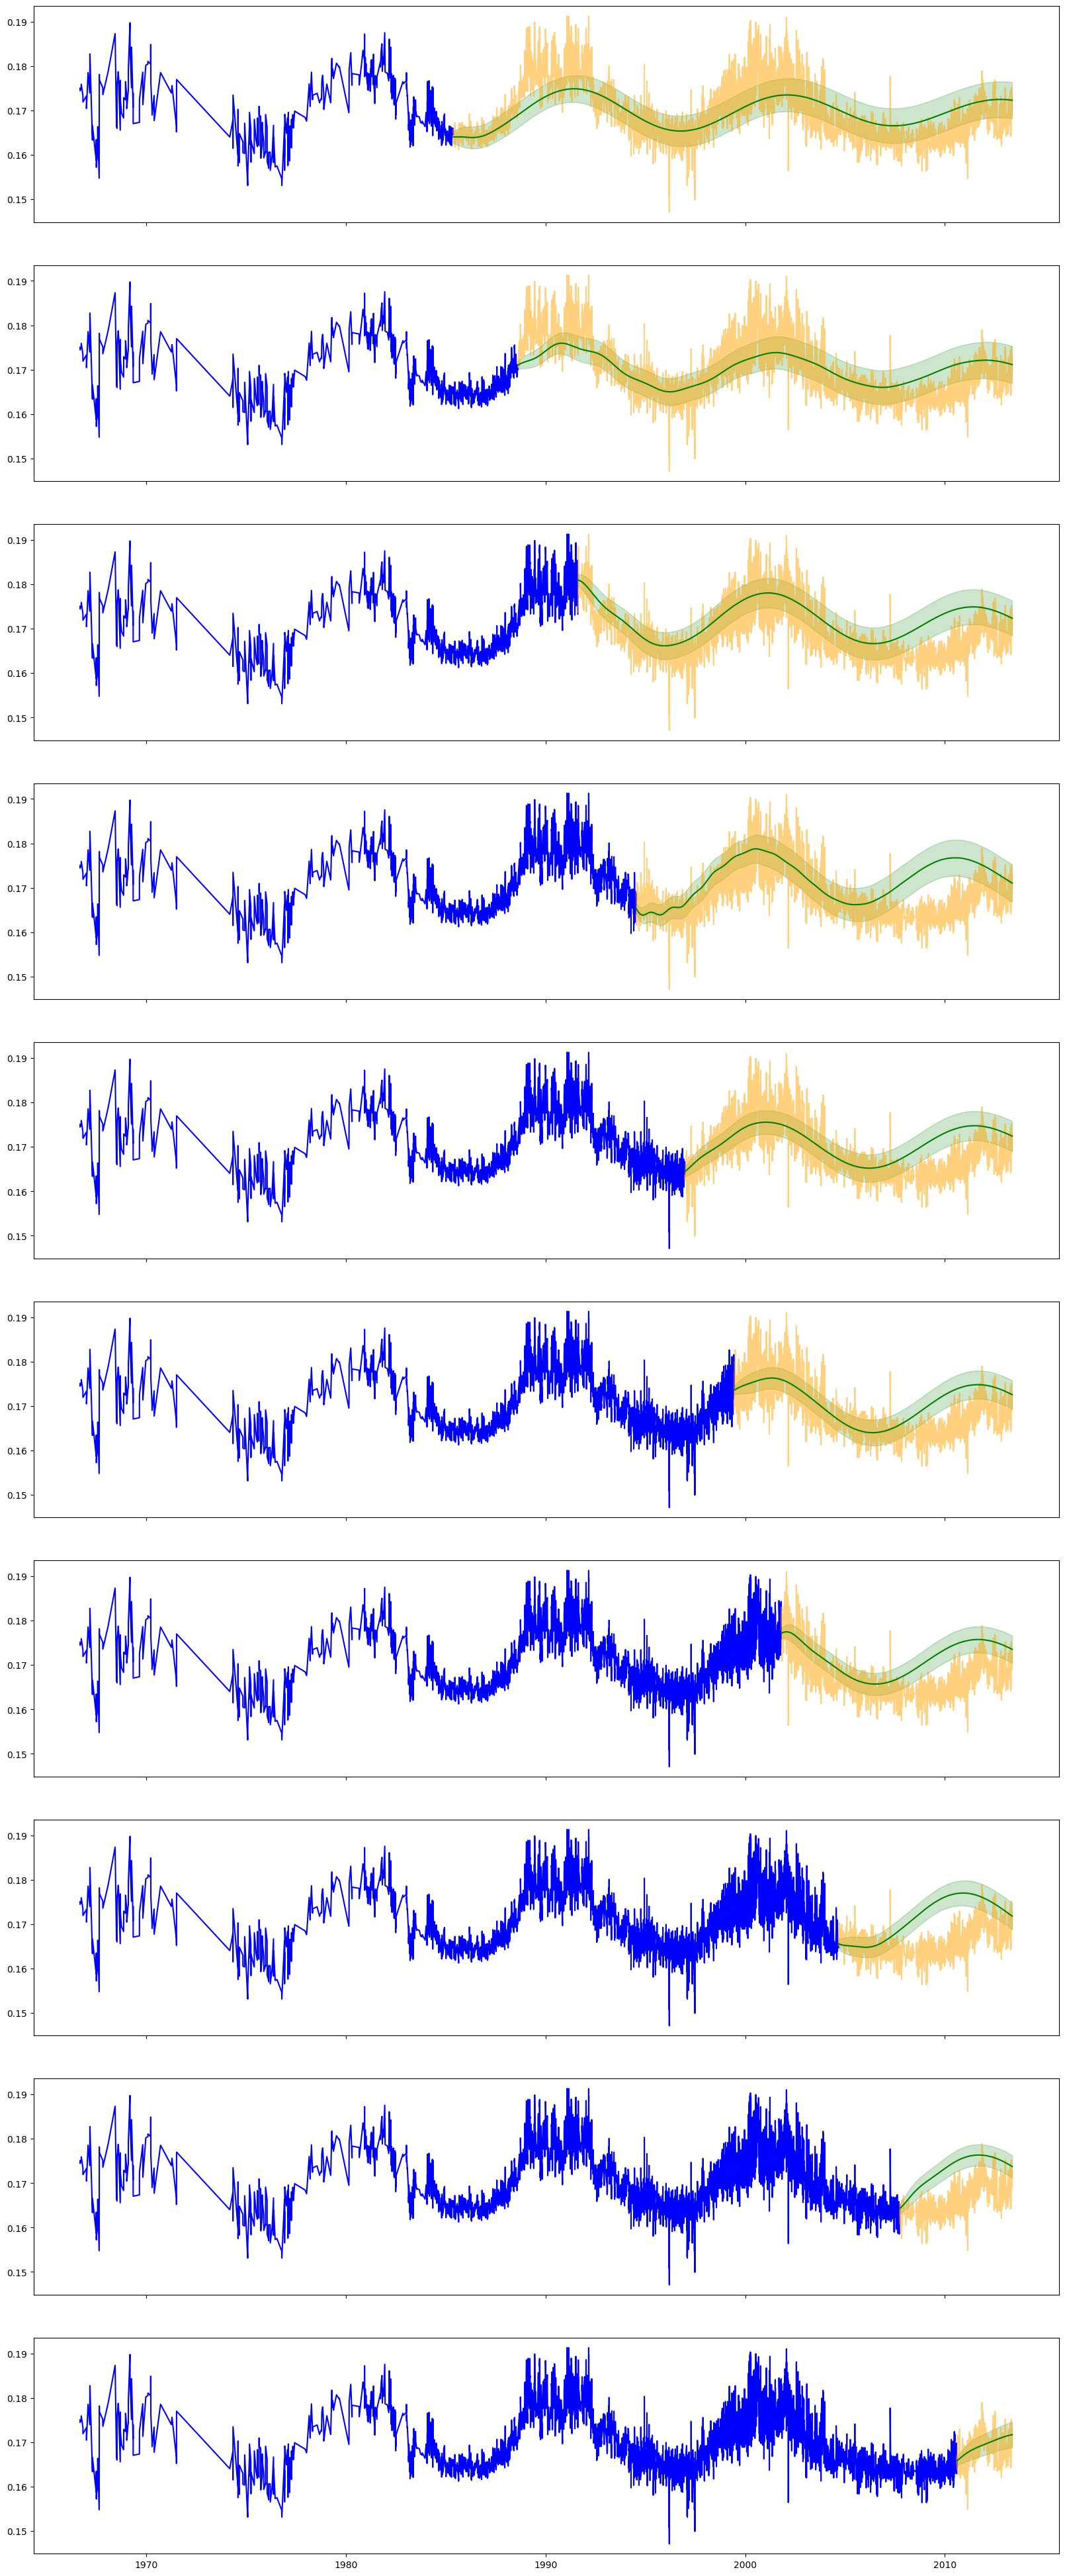

In [19]:
def plot_moving_window(data = data, n_windows = 10, train_low = 0.1, train_high = 0.9):
    fig, axes = plt.subplots(n_windows, 1, figsize=(20, 5 * n_windows), sharex= True, sharey= True)
    train_splits = np.linspace(train_low, train_high, n_windows)

    for idx, train_split in enumerate(train_splits):
        train_split *= 0.95
        valid_split = 0.95 - train_split
        train_test_model(train_split = train_split, valid_split = valid_split, k = 3, verbose = False, ax = axes[idx])

    plt.show()

plot_moving_window()
